# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Vincent Valentino | 5054251016 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [47]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from dython.nominal import associations
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score

In [48]:
ins = pd.read_csv("insurance.csv")
display(ins.shape)
display(ins.head())

(1338, 7)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [49]:
print(ins.duplicated().sum())
ins.isna().sum()

1


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [50]:
numerical = ins.select_dtypes(include=np.number).columns.tolist()
categorical = ins.select_dtypes(include=str).columns.tolist()

display(ins[numerical].describe())
display(ins[categorical].describe())

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


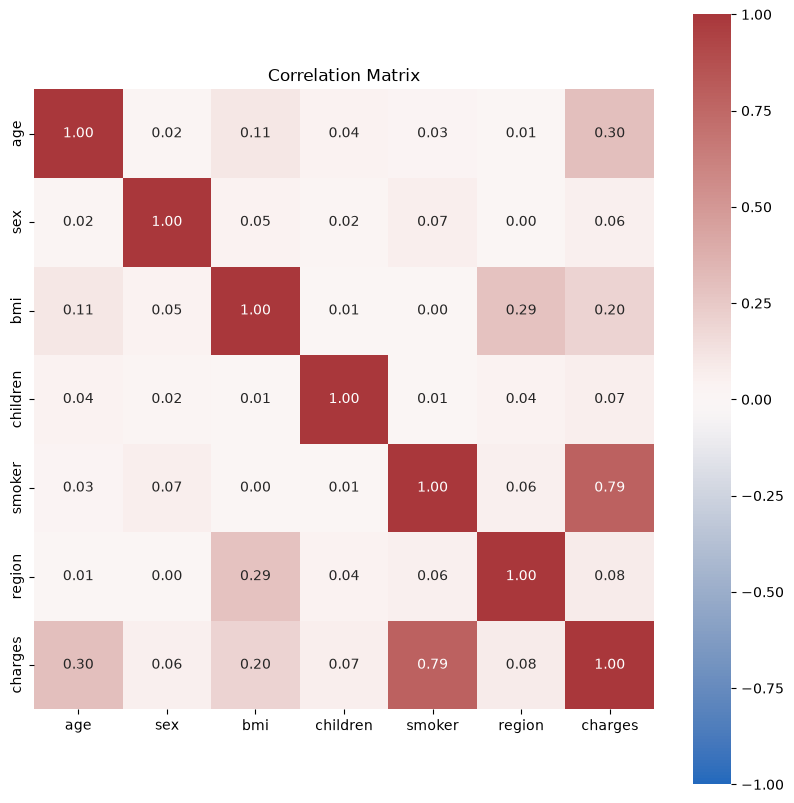

In [51]:
results = associations(ins, cmap="vlag", figsize=(10, 10), title="Correlation Matrix")

In [52]:
charge = np.where(ins['charges'] > ins['charges'].median(),'High','Low')

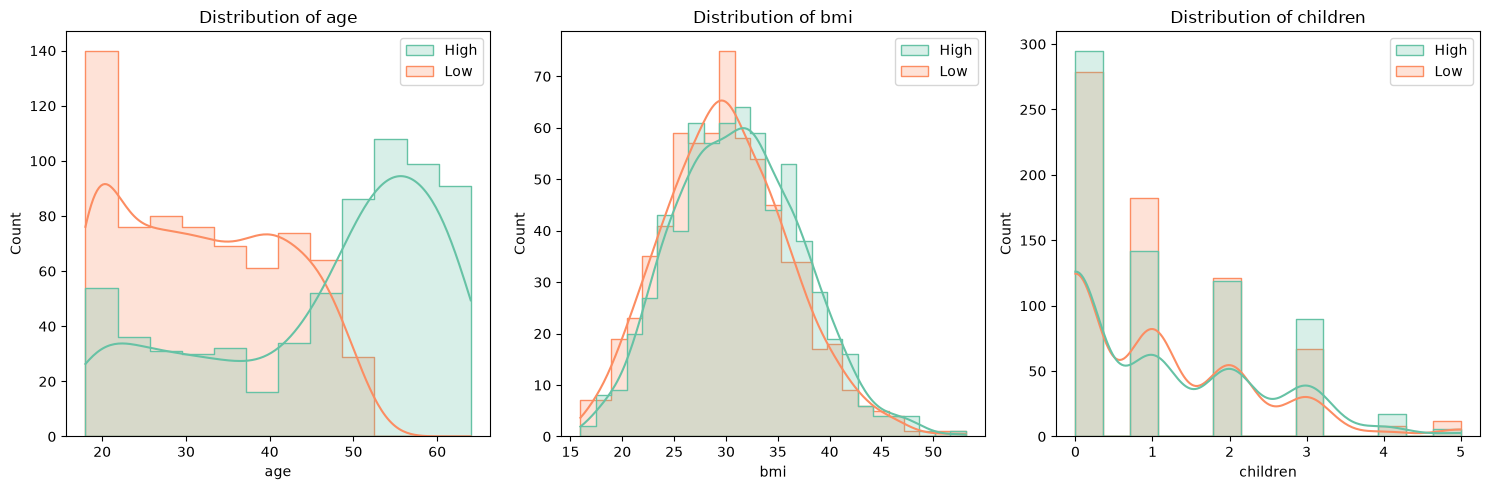

In [53]:
features = ins.drop(columns=categorical)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sb.histplot(data=ins, x=col, hue=charge, kde=True, palette='Set2', element='step', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

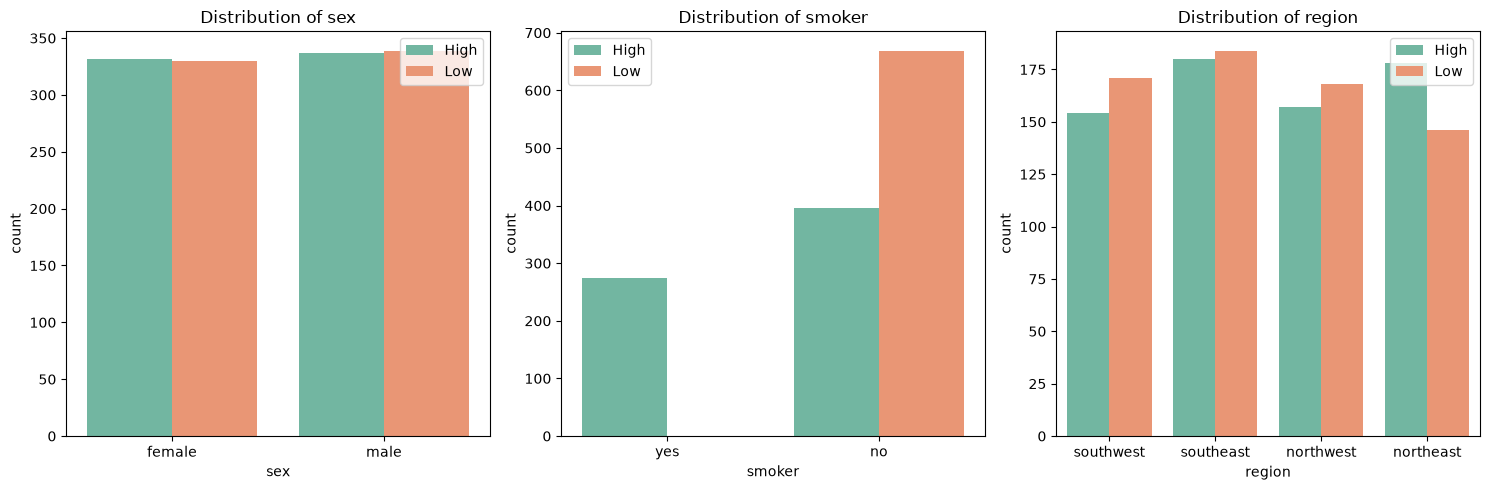

In [54]:
features = ins.drop(columns=numerical)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sb.countplot(data=ins, x=col, hue=charge, palette='Set2', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [55]:
ins = ins.drop_duplicates().reset_index(drop=True)


In [56]:
encoder = OneHotEncoder(drop="first", sparse_output=False)
cat_encoded = encoder.fit_transform(ins[categorical])
cat_encoded_df = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(categorical), index=ins.index)

In [57]:
concatenated_df = pd.concat([ins[numerical], cat_encoded_df], axis=1)

In [58]:
x = concatenated_df.drop(columns='charges')
y = ins['charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

In [59]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Polynomial Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1))
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=1000, epsilon=0.2))
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeRegressor(random_state=42, max_depth=5, min_samples_leaf=20))
    ])
}

# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [60]:
lr = models['Linear Regression'].fit(x_train, y_train)
lr_pred = lr.predict(x_test)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [61]:
pr = models['Polynomial Regression'].fit(x_train, y_train)
pr_pred = pr.predict(x_test)

## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [62]:
ridge = models['Ridge'].fit(x_train, y_train)
r_pred = ridge.predict(x_test)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [ ]:
lasso = models['Lasso'].fit(x_train, y_train)
l_pred = lasso.predict(x_test)


## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [ ]:
dt = models['Decision Tree'].fit(x_train, y_train)
dt_pred = dt.predict(x_test)


## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [ ]:
svr = models['SVR'].fit(x_train, y_train)
svr_pred = svr.predict(x_test)

# 4. Evaluasi Model

In [ ]:
predictions = {
    "Linear Regression": lr_pred,
    "Polynomial Regression": pr_pred,
    "Ridge": r_pred,
    "Lasso": l_pred,
    "SVR": svr_pred,
    "Decision Tree": dt_pred
}

results = []

for name, pred in predictions.items():
    mse = mean_squared_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    })

results_df = pd.DataFrame(results)
results_df.sort_values("R²", ascending=False)

,Model,MSE,RMSE,MAE,R²
5,Decision Tree,1.822076e+07,4268.578467,2649.393492,0.900843
1,Polynomial Regression,2.158584e+07,4646.056793,2867.317439,0.882530
0,Linear Regression,3.547802e+07,5956.342894,4177.045561,0.806929
3,Lasso,3.547875e+07,5956.404384,4177.062446,0.806925
2,Ridge,3.551247e+07,5959.234416,4179.621622,0.806741
4,SVR,5.455411e+07,7386.075171,3422.034430,0.703117


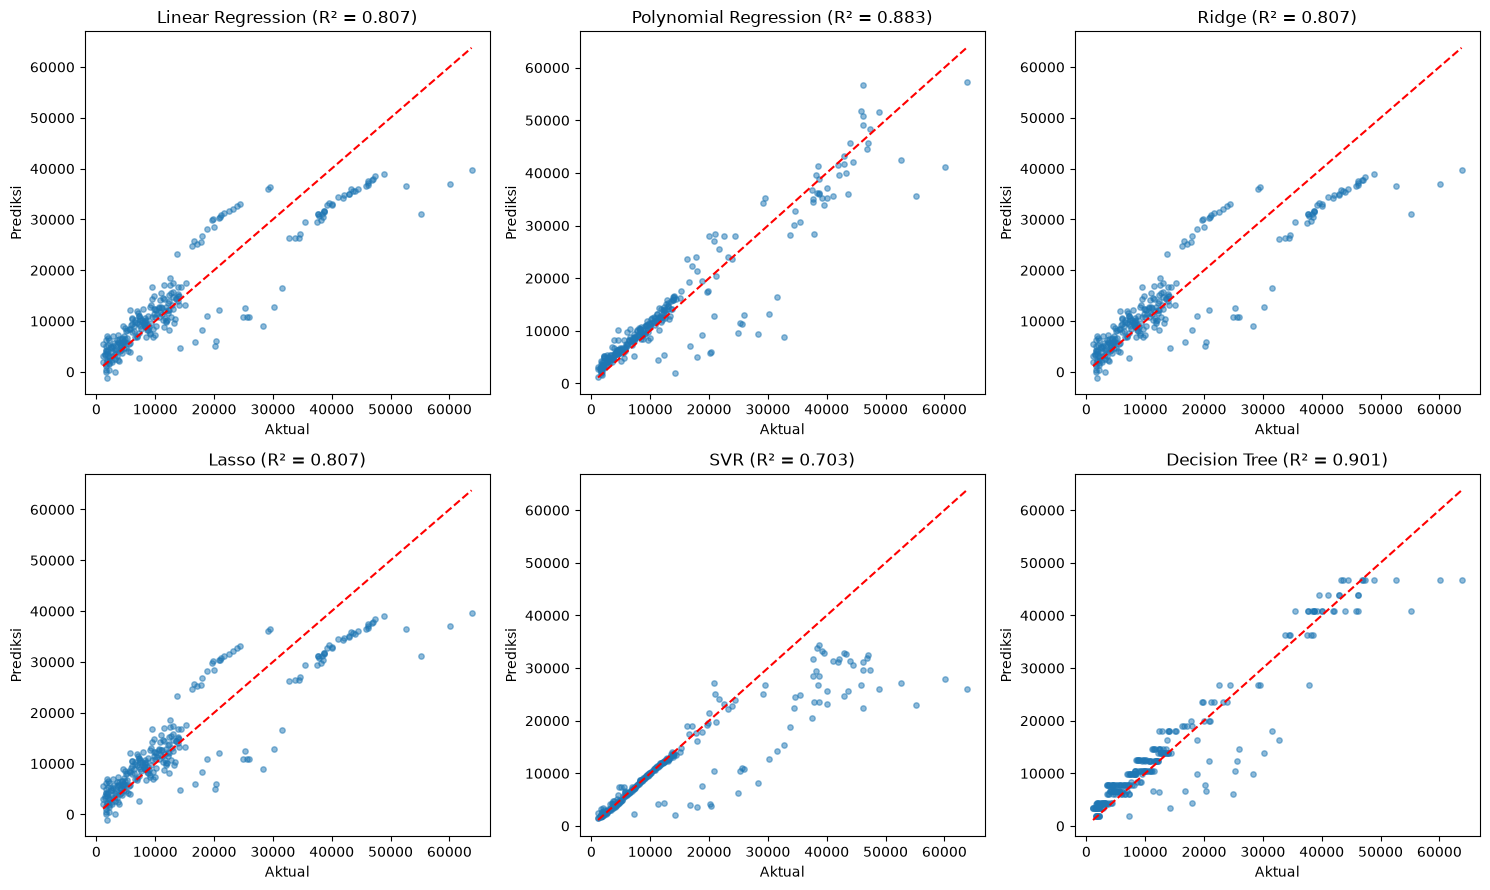

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
lims = [y_test.min(), y_test.max()]

for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, pred, alpha=0.5, s=15)
    ax.plot(lims, lims, "r--")
    ax.set_title(f"{name} (R² = {r2_score(y_test, pred):.3f})")
    ax.set_xlabel("Aktual")
    ax.set_ylabel("Prediksi")

plt.tight_layout()
plt.show()

# 5. Analisis

**Perbandingan Performa Model**:
- Decision Tree merupakan model dengan performa terbaik pada pengujian ini, menghasilkan nilai $R^2$ tertinggi (0.9008) dan RMSE terkecil (4268.5). Hal ini mengindikasikan bahwa Decision Tree sangat baik dalam memetakan pola non-linear dan mengekstrak aturan batas yang kuat (seperti pengaruh dominan dari fitur `smoker`).
- Polynomial Regression berada di urutan kedua dengan $R^2$ 0.8825. Penambahan fitur berderajat 2 membantu regresi linear biasa untuk menangkap efek interaksi antar variabel (misalnya efek `smoker` digabung dengan `bmi` yang terbukti saling memengaruhi drastis pada biaya asuransi).
- Model linear standar (Linear Regression, Ridge, Lasso) memiliki performa yang identik, dengan $R^2$ sekitar 0.806. Regularisasi L1 dan L2 (Lasso dan Ridge) tidak memberikan peningkatan yang signifikan dari baseline linier karena jumlah fitur pada dataset relatif sedikit dan tidak terjadi multikolinearitas atau overfitting yang berlebihan.
- Support Vector Regressor (SVR) memberikan nilai $R^2$ paling rendah (0.7031) dan RMSE tertinggi, yang berarti SVR kesulitan menjelaskan varians data secara keseluruhan. Namun menariknya, nilai MAE SVR (3422) justru lebih baik dibandingkan keluarga model regresi linear (4177). Hal ini mengindikasikan SVR lebih robust dan kebal terhadap *outlier* saat meminimalkan error absolut, namun melenceng cukup jauh pada beberapa nilai ekstrem (biaya asuransi yang sangat tinggi) sehingga menyebabkan error kuadrat (MSE/RMSE) membengkak.

**Pengaruh Pre-processing**:
- Dataset telah diproses untuk menangani nilai kategorikal. Namun, yang paling krusial adalah penerapan `StandardScaler` (sebagaimana terlihat di arsitektur `Pipeline`). Scaling sangat vital terutama untuk model Polynomial Regression, Ridge, Lasso, dan SVR yang mengandalkan metrik jarak/penalti dan sangat sensitif terhadap skala data. Tanpa *scaling*, fitur `bmi` (puluhan) dan fitur polinomial berderajat tinggi akan mendominasi pembobotan.
- Di sisi lain, *Decision Tree* pada dasarnya tidak membutuhkan feature scaling karena algoritma ini membagi data berdasarkan batas diskrit (*threshold split*), membuatnya kebal terhadap rentang nilai asli atribut.

**Pengaruh Parameter**:
- Pada Decision Tree, penggunaan `max_depth=5` dan `min_samples_leaf=20` berperan untuk menahan tree agar tidak bertumbuh terlalu dalam yang bisa mengakibatkan *verfitting.
- Pada Polynomial Regression, penggunaan `degree=2` merupakan batasan yang masuk akal guna mencegah fenomena Curse of Dimensionality. Jika menaikkan orde terlalu tinggi, jumlah fitur akan meledak dan menyebabkan model linear rentan overfit.
- Pada SVR, parameter `kernel="rbf"`, `C=1000`, dan `epsilon=0.2` mengendalikan batasan error dan kehalusan regresi. Jika tidak dikendalikan, $R^2$ akan negatif.

# 6. Kesimpulan dan Saran

**Kesimpulan:**
1. Decision Tree dan Polynomial Regression terbukti paling efektif dalam menangkap pola tersebut, mengungguli model linear berdimensi satu.
3. Regularisasi linier (Ridge/Lasso) belum menunjukkan manfaat di kasus ini akibat kurangnya dimensi features.
4. Perbedaan nilai error (MAE yang kecil namun RMSE/MSE yang besar) pada prediksi SVR menggarisbawahi pentingnya memilih metrik evaluasi yang tepat saat berhadapan dengan *outlier*.

Saran:
1. Eksperimen Lanjutan: Mengingat pendekatan *tree-based* memberikan hasil optimal, disarankan untuk mengimplementasikan algoritma seperti *Random Forest* atau *Gradient Boosting* (XGBoost, LightGBM).
2. Transformasi Target: Distribusi dari atribut target (Biaya Asuransi / `charges`) biasanya menceng kanan (*right-skewed*). Sangat dianjurkan untuk memberikan pre-processing Log Transformation (`np.log1p`).